# Linear vs Non-Linear Compression: SVD vs Autoencoder


### Linear Methods (SVD/PCA)
- Find the optimal linear subspace that captures maximum variance
- Artifacts: Blocky artifacts, especially at edges (Gibbs phenomenon)
- Training: None required (closed-form solution)

### Non-Linear Methods (Autoencoders)
- Learn a non-linear manifold through neural network optimization
- Artifacts: Blurry reconstructions, loss of fine details
- Training: Requires iterative optimization (gradient descent)

In [14]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.svd import TruncatedSVD
from src.autoencoder import ConvAutoencoder
from src.metrics import relative_error, psnr
from data.synthetic import create_sample_image

# Check device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

def compression_ratio(shape, k):
    m, n = shape
    return (m * n) / (k * (m + n + 1))

def ssim(img1, img2):
    # Simplified SSIM for demonstration purposes
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    
    mu1 = img1.mean()
    mu2 = img2.mean()
    sigma1_sq = img1.var()
    sigma2_sq = img2.var()
    sigma12 = np.cov(img1.flatten(), img2.flatten())[0, 1]
    
    ssim_map = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / ((mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2))
    return ssim_map

Using device: mps
PyTorch version: 2.0.0


## 1. Load and Prepare Image

Image shape: (256, 256)
Image range: [0.000, 1.000]


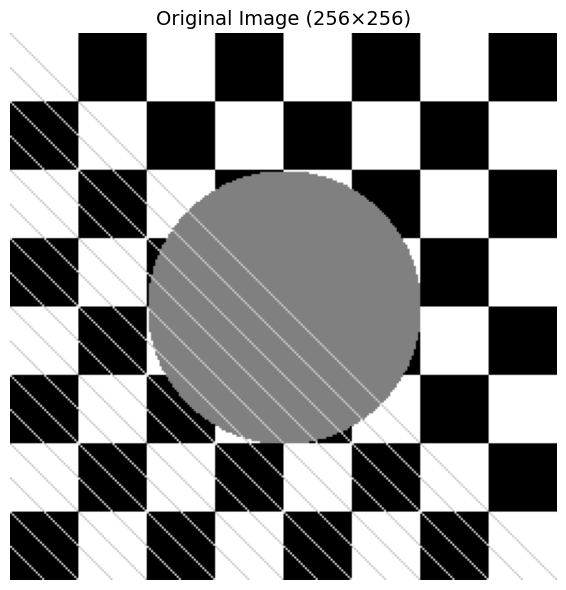

In [15]:
# Load image and normalize to [0, 1]
image = create_sample_image(256).astype(np.float32) / 255.0

print(f"Image shape: {image.shape}")
print(f"Image range: [{image.min():.3f}, {image.max():.3f}]")

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title('Original Image (256×256)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. SVD Compression (Linear Baseline)

Compress the image using various ranks to establish our linear baseline.

In [16]:
# SVD compression at different ranks
svd_ranks = [5, 10, 20, 50]
svd_results = {}

print("SVD Compression Results:")
print("-" * 65)
print(f"{'Rank':>6} | {'Compression':>12} | {'PSNR (dB)':>10} | {'SSIM':>8}")
print("-" * 65)

for k in svd_ranks:
    svd = TruncatedSVD(n_components=k)
    svd.fit(image)
    recon = np.clip(svd.reconstruct(), 0, 1)
    
    comp = compression_ratio(image.shape, k)
    p = psnr(image, recon, max_val=1.0)
    s = ssim(image, recon)
    
    svd_results[k] = {
        'reconstruction': recon,
        'compression': comp,
        'psnr': p,
        'ssim': s
    }
    
    print(f"{k:>6} | {comp:>11.2f}x | {p:>10.2f} | {s:>8.4f}")

print("-" * 65)

SVD Compression Results:
-----------------------------------------------------------------
  Rank |  Compression |  PSNR (dB) |     SSIM
-----------------------------------------------------------------
     5 |       25.55x |      20.11 |   0.9746
    10 |       12.78x |      21.06 |   0.9795
    20 |        6.39x |      23.27 |   0.9878
    50 |        2.56x |      29.70 |   0.9972
-----------------------------------------------------------------


## 3. Train Convolutional Autoencoder (Non-Linear)

Now train autoencoders with bottleneck dimensions that give similar compression ratios.

In [17]:
# Create training data by adding augmented versions
# For a single image, we create synthetic "dataset" through augmentation
def create_training_data(img, n_samples=500):
    data = [img]
    
    for _ in range(n_samples - 1):
        # Small random noise
        noisy = img + np.random.randn(*img.shape) * 0.02
        noisy = np.clip(noisy, 0, 1)
        data.append(noisy.astype(np.float32))
    
    return np.array(data)

X_train = create_training_data(image, n_samples=500)
print(f"Training data shape: {X_train.shape}")

Training data shape: (500, 256, 256)


In [ ]:
ae_latent_channels = [1, 2, 4, 8]
ae_results = {}

for latent_channels in ae_latent_channels:
    print(f"\n{'='*50}")
    print(f"Training Autoencoder with latent_channels={latent_channels}")
    print(f"{'='*50}")
    
    model = ConvAutoencoder(
        n_filters=32,
        latent_channels=latent_channels,
        learning_rate=1e-3,
        n_epochs=20,
        batch_size=32
    )
    
    model.fit(X_train, verbose=True)
    
    # Reconstruct original image
    recon = model.reconstruct(image[np.newaxis, :, :])[0]
    recon = np.clip(recon, 0, 1)
    
    # latent representation is H/4 x W/4
    # Image is 256x256, so latent is 64x64
    comp = (256 * 256) / (latent_channels * 64 * 64)
    p = psnr(image, recon, max_val=1.0)
    s = ssim(image, recon)
    
    ae_results[latent_channels] = {
        'reconstruction': recon,
        'compression': comp,
        'psnr': p,
        'ssim': s,
        'history': model.loss_history_
    }
    
    print(f"\nResults: Compression={comp:.1f}x, PSNR={p:.2f}dB, SSIM={s:.4f}")


Training Autoencoder with latent_channels=1
Epoch 10/20, Loss: 0.027622
Epoch 20/20, Loss: 0.007824

Results: Compression=16.0x, PSNR=21.01dB, SSIM=0.9783

Training Autoencoder with latent_channels=2
Epoch 10/20, Loss: 0.191274
Epoch 20/20, Loss: 0.191010

Results: Compression=8.0x, PSNR=7.06dB, SSIM=0.0051

Training Autoencoder with latent_channels=4
Epoch 10/20, Loss: 0.011173
Epoch 20/20, Loss: 0.005457

Results: Compression=4.0x, PSNR=22.79dB, SSIM=0.9861

Training Autoencoder with latent_channels=8
Epoch 10/20, Loss: 0.009297


In [ ]:
# Summary table
print("\nAutoencoder Compression Results:")
print("-" * 65)
print(f"{'Latent Ch':>10} | {'Compression':>12} | {'PSNR (dB)':>10} | {'SSIM':>8}")
print("-" * 65)

for latent_channels, results in ae_results.items():
    print(f"{latent_channels:>10} | {results['compression']:>11.1f}x | {results['psnr']:>10.2f} | {results['ssim']:>8.4f}")

print("-" * 65)


Autoencoder Compression Results:
-----------------------------------------------------------------
 Latent Ch |  Compression |  PSNR (dB) |     SSIM
-----------------------------------------------------------------
         1 |        16.0x |      13.07 |   0.8550
         2 |         8.0x |      20.69 |   0.9765
         4 |         4.0x |      25.25 |   0.9922
         8 |         2.0x |      24.78 |   0.9913
-----------------------------------------------------------------


## 4. Visual Comparison: Linear vs Non-Linear Artifacts

This is the key comparison - observe the **qualitative differences** in artifacts.

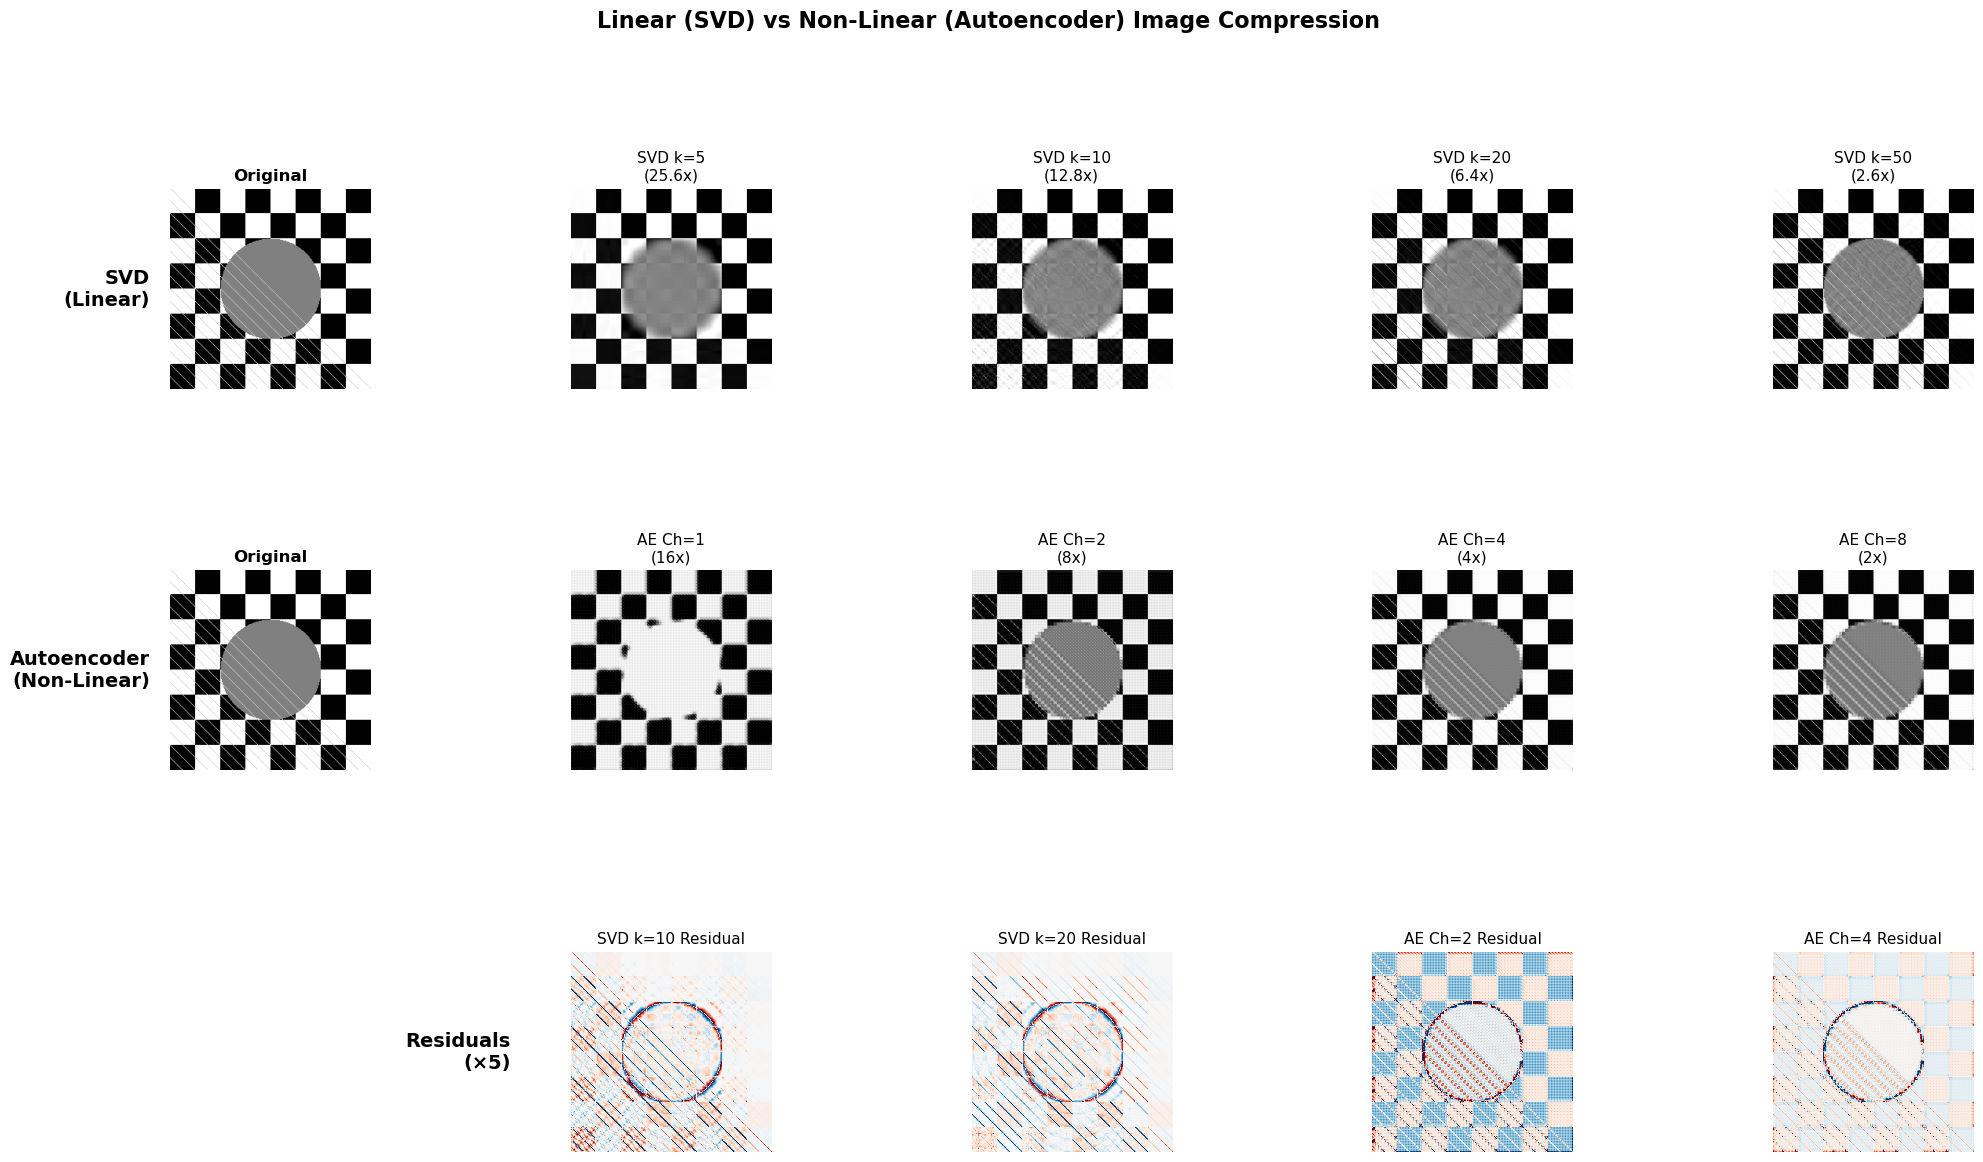

In [ ]:
# Side-by-side comparison
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

# Row 0: Original + SVD reconstructions
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

for i, k in enumerate(svd_ranks):
    axes[0, i+1].imshow(svd_results[k]['reconstruction'], cmap='gray')
    axes[0, i+1].set_title(f'SVD k={k}\n({svd_results[k]["compression"]:.1f}x)', fontsize=11)
    axes[0, i+1].axis('off')

# Row 1: Autoencoder reconstructions
axes[1, 0].imshow(image, cmap='gray')
axes[1, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

for i, latent_channels in enumerate(ae_latent_channels):
    axes[1, i+1].imshow(ae_results[latent_channels]['reconstruction'], cmap='gray')
    axes[1, i+1].set_title(f'AE Ch={latent_channels}\n({ae_results[latent_channels]["compression"]:.0f}x)', fontsize=11)
    axes[1, i+1].axis('off')

# Row 2: Residuals (amplified)
axes[2, 0].set_visible(False)

# SVD residuals
for i, k in enumerate([10, 20]):
    residual = image - svd_results[k]['reconstruction']
    axes[2, i+1].imshow(residual, cmap='RdBu', vmin=-0.2, vmax=0.2)
    axes[2, i+1].set_title(f'SVD k={k} Residual', fontsize=11)
    axes[2, i+1].axis('off')

# AE residuals
for i, latent_channels in enumerate([2, 4]):
    residual = image - ae_results[latent_channels]['reconstruction']
    axes[2, i+3].imshow(residual, cmap='RdBu', vmin=-0.2, vmax=0.2)
    axes[2, i+3].set_title(f'AE Ch={latent_channels} Residual', fontsize=11)
    axes[2, i+3].axis('off')

# Labels
axes[0, 0].text(-0.1, 0.5, 'SVD\n(Linear)', transform=axes[0, 0].transAxes,
               fontsize=14, fontweight='bold', va='center', ha='right')
axes[1, 0].text(-0.1, 0.5, 'Autoencoder\n(Non-Linear)', transform=axes[1, 0].transAxes,
               fontsize=14, fontweight='bold', va='center', ha='right')
axes[2, 1].text(-0.3, 0.5, 'Residuals\n(×5)', transform=axes[2, 1].transAxes,
               fontsize=14, fontweight='bold', va='center', ha='right')

fig.suptitle('Linear (SVD) vs Non-Linear (Autoencoder) Image Compression', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Zoomed Artifact Analysis

Let's zoom into a region with fine details to better see the artifact differences.

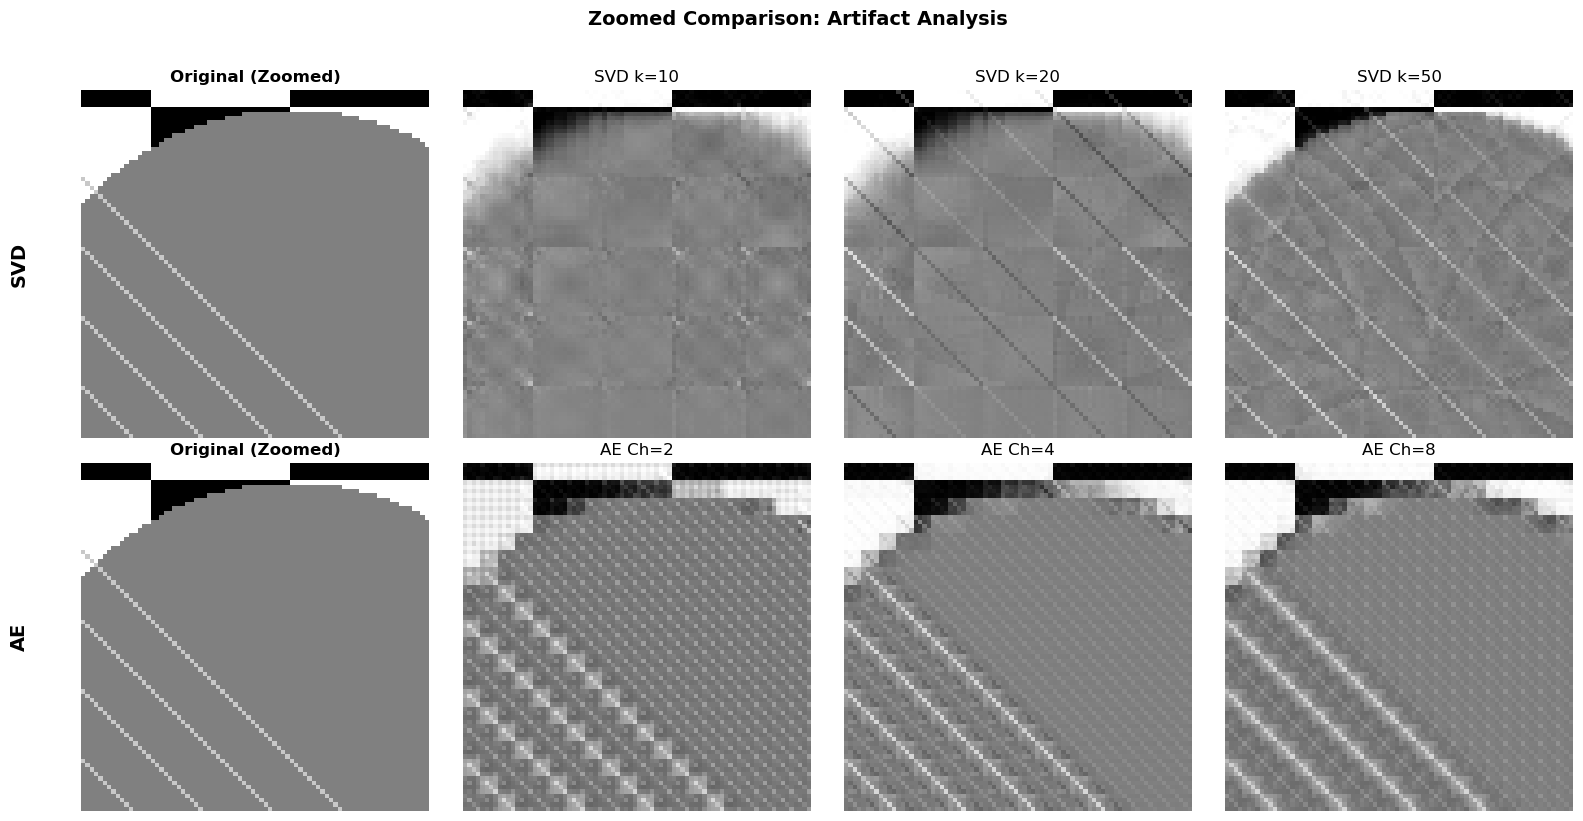

In [ ]:
# Zoom into a region with edges/details
zoom_region = (slice(60, 140), slice(80, 160))  # Crop region

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original
axes[0, 0].imshow(image[zoom_region], cmap='gray')
axes[0, 0].set_title('Original (Zoomed)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[1, 0].imshow(image[zoom_region], cmap='gray')
axes[1, 0].set_title('Original (Zoomed)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# SVD zoomed
for i, k in enumerate([10, 20, 50]):
    axes[0, i+1].imshow(svd_results[k]['reconstruction'][zoom_region], cmap='gray')
    axes[0, i+1].set_title(f'SVD k={k}', fontsize=12)
    axes[0, i+1].axis('off')

# AE zoomed
for i, latent_channels in enumerate([2, 4, 8]):
    axes[1, i+1].imshow(ae_results[latent_channels]['reconstruction'][zoom_region], cmap='gray')
    axes[1, i+1].set_title(f'AE Ch={latent_channels}', fontsize=12)
    axes[1, i+1].axis('off')

axes[0, 0].text(-0.15, 0.5, 'SVD', transform=axes[0, 0].transAxes,
               fontsize=14, fontweight='bold', va='center', ha='right', rotation=90)
axes[1, 0].text(-0.15, 0.5, 'AE', transform=axes[1, 0].transAxes,
               fontsize=14, fontweight='bold', va='center', ha='right', rotation=90)

fig.suptitle('Zoomed Comparison: Artifact Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Quantitative Comparison: PSNR vs Compression

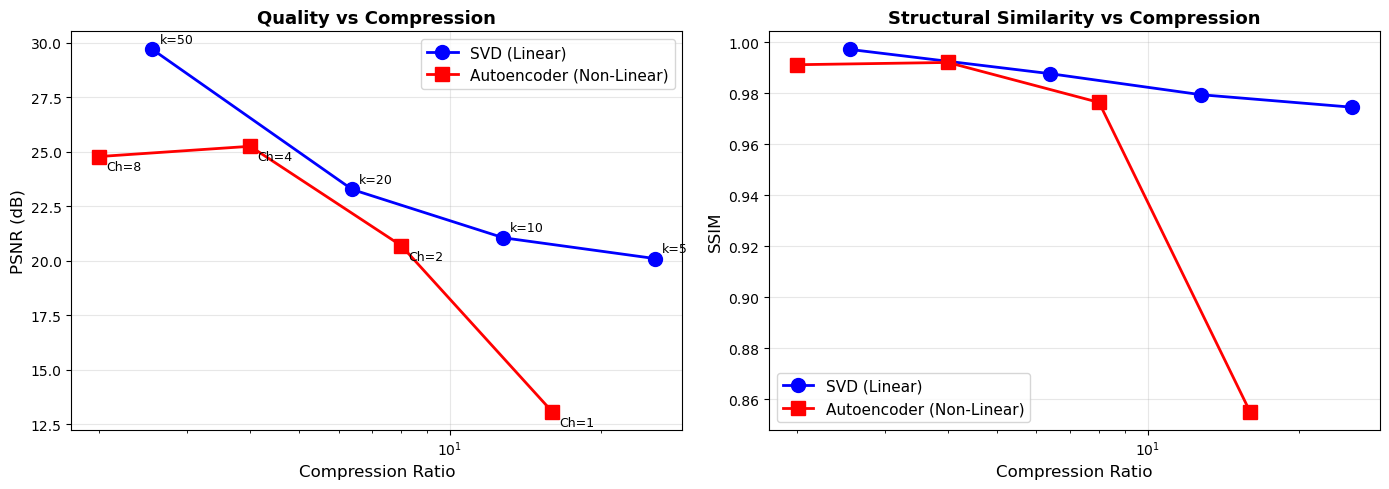

In [ ]:
# Plot PSNR vs Compression ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PSNR comparison
ax1 = axes[0]

svd_comp = [svd_results[k]['compression'] for k in svd_ranks]
svd_psnr = [svd_results[k]['psnr'] for k in svd_ranks]

ae_comp = [ae_results[d]['compression'] for d in ae_latent_channels]
ae_psnr = [ae_results[d]['psnr'] for d in ae_latent_channels]

ax1.plot(svd_comp, svd_psnr, 'bo-', markersize=10, linewidth=2, label='SVD (Linear)')
ax1.plot(ae_comp, ae_psnr, 'rs-', markersize=10, linewidth=2, label='Autoencoder (Non-Linear)')

# Annotate points
for k, comp, p in zip(svd_ranks, svd_comp, svd_psnr):
    ax1.annotate(f'k={k}', (comp, p), xytext=(5, 5), textcoords='offset points', fontsize=9)
for d, comp, p in zip(ae_latent_channels, ae_comp, ae_psnr):
    ax1.annotate(f'Ch={d}', (comp, p), xytext=(5, -10), textcoords='offset points', fontsize=9)

ax1.set_xlabel('Compression Ratio', fontsize=12)
ax1.set_ylabel('PSNR (dB)', fontsize=12)
ax1.set_title('Quality vs Compression', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# SSIM comparison
ax2 = axes[1]

svd_ssim = [svd_results[k]['ssim'] for k in svd_ranks]
ae_ssim = [ae_results[d]['ssim'] for d in ae_latent_channels]

ax2.plot(svd_comp, svd_ssim, 'bo-', markersize=10, linewidth=2, label='SVD (Linear)')
ax2.plot(ae_comp, ae_ssim, 'rs-', markersize=10, linewidth=2, label='Autoencoder (Non-Linear)')

ax2.set_xlabel('Compression Ratio', fontsize=12)
ax2.set_ylabel('SSIM', fontsize=12)
ax2.set_title('Structural Similarity vs Compression', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

## 7. Training Dynamics

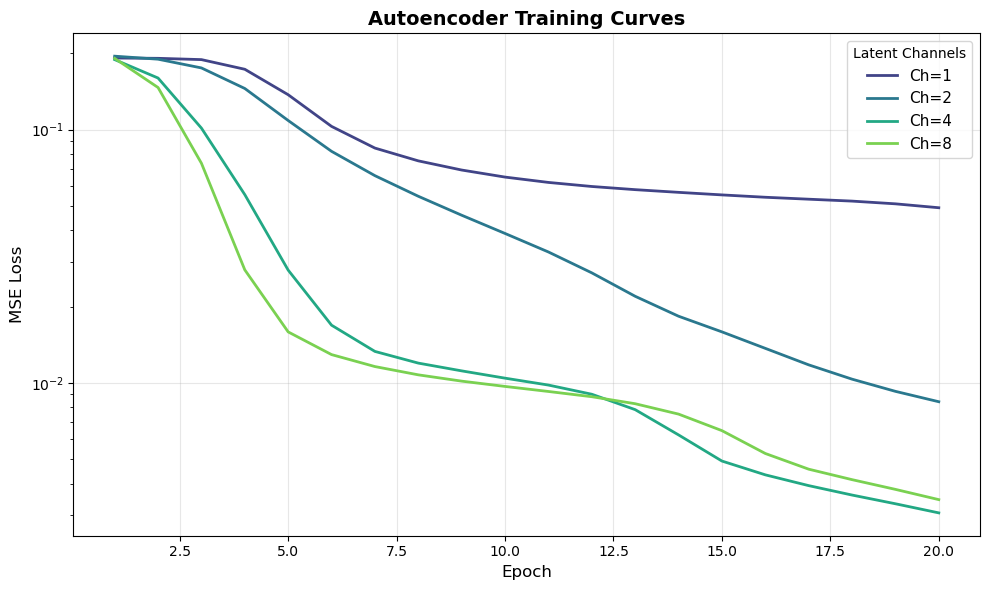

In [ ]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(ae_latent_channels)))

for i, (latent_channels, results) in enumerate(ae_results.items()):
    epochs = range(1, len(results['history']) + 1)
    ax.plot(epochs, results['history'], 
            color=colors[i], linewidth=2, label=f'Ch={latent_channels}')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Autoencoder Training Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, title='Latent Channels')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## Summary


| Aspect | SVD (Linear) | Autoencoder (Non-Linear) |
|--------|--------------|-------------------------|
| **Artifacts** | Blocky, ringing at edges | Blurry, smoothed details |
| **High-frequency** | Preserved but quantized | Lost (low-pass filtered) |
| **Training** | None (closed-form) | Requires optimization |
| **Generalization** | Perfect (deterministic) | Depends on training |

### Key Takeaways

1. **SVD superiority at very low compression**: Linear methods capture global structure efficiently, whereas autoencoders require much higher capacity to learn the mapping effectively.
2. **Autoencoder blurring effects**: Autoencoders tend to produce blurry reconstructions because MSE loss penalizes pixel-wise error, leading the network to predict "average" pixel values to minimize this loss.
3. **Appropriate use cases**:
   - **SVD**: Best suited when you need theoretical guarantees, interpretability, or when working with limited data.
   - **Autoencoder**: Best suited when data lies on a complex non-linear manifold and large datasets are available for training.
4. **Potential autoencoder improvements**: Non-linear models can be improved by incorporating perceptual loss (e.g., VGG features), adversarial training (GANs), or skip connections (e.g., U-Net architecture).